<a href="https://www.kaggle.com/code/avikdas567/ufc-fight-data-analysis-prediction-through-2026?scriptVersionId=320248675" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# UFC Fight Data Through April 2026  
### Exploratory Data Analysis, fight trends, and outcome prediction

This notebook analyzes two UFC fight datasets covering professional bouts from 2010 through April 2026.

- **Historical dataset**: `testing.csv`  
  6,528 fights across 57 columns spanning **2010-03-21 to 2024-12-07**

- **Recent fight dataset**: `recent_fights.csv`  
  688 fights across 57 columns spanning **2024-12-14 to 2026-04-18**

The goal of this analysis is to explore fight-level trends, examine pre-fight statistical signals, and evaluate how well fight outcomes can be predicted using machine learning.

The notebook workflow includes:

1. Data loading and cleaning  
2. Exploratory Data Analysis (EDA)  
3. Missing value analysis  
4. Fighter and matchup trend analysis  
5. Time-based train/test evaluation  
6. Machine learning benchmarking  
7. Feature importance analysis  
8. Final insights and takeaways  

For modeling, the historical dataset is used for training while the newer fights are reserved as an out-of-time test set to better simulate a real-world prediction setup.

To avoid target leakage, payout-related columns such as `RedReturn` and `BlueReturn` are excluded from the predictive models because they directly encode post-fight outcomes.


## 1) Imports and configuration


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
)
from catboost import CatBoostClassifier, Pool

plt.style.use("default")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

SEED = 42
np.random.seed(SEED)


## 2) Load both datasets


In [2]:
historical_path = "/kaggle/input/datasets/anthonysz/ufc-fight-data-2026/testing.csv"
recent_path = "/kaggle/input/datasets/anthonysz/ufc-fight-data-2026/recent_fights.csv"

historical = pd.read_csv(historical_path)
recent = pd.read_csv(recent_path)

print("historical shape:", historical.shape)
print("recent shape:", recent.shape)
display(historical.head())
display(recent.head())

historical shape: (6528, 57)
recent shape: (688, 57)


,RedFighter,BlueFighter,RedOdds,BlueOdds,RedWinner,RedReturn,BlueReturn,OddsDiff,AgeDiff,ReachDiff,HeightDiff,WinsDiff,LossesDiff,RoundsDiff,TitleBoutDiff,KODiff,SubmissionDiff,WinStreakDiff,LoseStreakDiff,LongestWinStreakDiff,SigStrDiff,SubAttDiff,TDDiff,RankDiff,Date,TitleBout,WeightClass,Gender,NumberOfRounds,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByKO,BlueWinsBySubmission,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,RedCurrentLoseStreak,RedCurrentWinStreak,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByKO,RedWinsBySubmission,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,BlueAge,BMatchWCRank,RMatchWCRank
0,Alexandre Pantoja,Kai Asakura,-250.0,215.0,True,1.4000,0.0,-465.0,3,-5.08,-7.62,12,3,42,3,2,4,6,0,6,-4.41,-0.8,-2.61,-20,2024-12-07,True,Flyweight,MALE,5,0,0,0,0,0,0,0,0,0,Orthodox,172.72,175.26,0,6,6,3,42,3,2,4,12,Orthodox,165.10,170.18,34,31,20,0
1,Shavkat Rakhmonov,Ian Machado Garry,-210.0,295.0,True,1.4762,0.0,-505.0,3,7.62,-5.08,-2,0,-9,0,-2,5,-2,0,-2,1.38,-1.5,-0.72,-4,2024-12-07,False,Welterweight,MALE,3,0,8,8,0,20,0,3,0,8,Orthodox,190.50,187.96,0,6,6,0,11,0,1,5,6,Orthodox,185.42,195.58,30,27,7,3
2,Ciryl Gane,Alexander Volkov,-380.0,300.0,True,1.2632,0.0,-680.0,-2,2.54,-7.62,-3,-2,-11,3,-2,1,-3,0,3,-0.36,-0.3,-0.13,-1,2024-12-07,False,Heavyweight,MALE,3,0,4,4,4,44,0,6,1,12,Orthodox,200.66,203.20,0,1,7,2,33,3,4,2,9,Orthodox,193.04,205.74,34,36,3,2
3,Bryce Mitchell,Kron Gracie,-950.0,625.0,True,1.1053,0.0,-1575.0,-6,0.00,2.54,6,0,15,0,0,0,0,-1,5,1.44,-1.1,-2.98,-7,2024-12-07,False,Featherweight,MALE,3,2,0,1,2,7,0,0,1,1,Southpaw,175.26,177.80,1,0,6,2,22,0,0,1,7,Southpaw,177.80,177.80,30,36,20,13
4,Nate Landwehr,Dooho Choi,-130.0,110.0,False,0.0000,2.1,-240.0,3,5.08,-2.54,1,0,2,0,-3,2,0,0,0,-1.84,-0.2,-0.25,0,2024-12-07,False,Featherweight,MALE,3,0,1,3,3,15,0,4,0,4,Orthodox,177.80,177.80,0,1,3,3,17,0,1,2,5,Orthodox,175.26,182.88,36,33,20,20


,RedFighter,BlueFighter,RedOdds,BlueOdds,RedWinner,RedReturn,BlueReturn,OddsDiff,AgeDiff,ReachDiff,HeightDiff,WinsDiff,LossesDiff,RoundsDiff,TitleBoutDiff,KODiff,SubmissionDiff,WinStreakDiff,LoseStreakDiff,LongestWinStreakDiff,SigStrDiff,SubAttDiff,TDDiff,RankDiff,Date,TitleBout,WeightClass,Gender,NumberOfRounds,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByKO,BlueWinsBySubmission,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,RedCurrentLoseStreak,RedCurrentWinStreak,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByKO,RedWinsBySubmission,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,BlueAge,BMatchWCRank,RMatchWCRank
0,Colby Covington,Joaquin Buckley,172.0,-205.0,False,0.0000,1.4878,377.0,6,-10.16,2.54,2,0,24,4,-4,2,-5,1,2,-0.07,0.1,2.10,-3,2024-12-14,False,Welterweight,MALE,5,0,5,5,4,34,0,7,0,10,Southpaw,177.80,193.04,1,0,7,4,58,4,3,2,12,Orthodox,180.34,182.88,36,30,9,6
1,Cub Swanson,Billy Quarantillo,140.0,-166.0,True,2.4000,0.0000,306.0,5,0.00,-5.08,12,9,54,0,2,1,0,0,2,-2.60,-0.6,-0.47,0,2024-12-14,False,Featherweight,MALE,3,1,0,4,4,28,0,4,1,7,Orthodox,177.80,177.80,1,0,6,13,82,0,6,2,19,Orthodox,172.72,177.80,41,36,20,20
2,Manel Kape,Bruno Silva,-360.0,250.0,True,1.2778,0.0000,-610.0,-3,7.62,2.54,0,1,1,0,-1,-1,-4,1,0,1.09,0.1,-1.61,-11,2024-12-14,False,Flyweight,MALE,3,0,4,4,2,16,0,3,1,4,Orthodox,162.56,165.10,1,0,4,3,17,0,2,0,4,Southpaw,165.10,172.72,31,34,20,9
3,Vitor Petrino,Dustin Jacoby,-320.0,260.0,False,0.0000,3.6000,-580.0,-9,2.54,-2.54,-3,-5,-21,0,-2,1,0,-1,1,-2.16,0.7,2.28,0,2024-12-14,False,Light Heavyweight,MALE,3,2,0,4,6,35,0,4,0,8,Orthodox,190.50,193.04,1,0,5,1,14,0,2,1,5,Orthodox,187.96,195.58,27,36,20,20
4,Adrian Yanez,Daniel Marcos,440.0,-700.0,False,0.0000,1.1429,1140.0,0,2.54,0.00,3,2,2,0,5,0,0,0,3,1.06,-0.1,-1.35,0,2024-12-14,False,Bantamweight,MALE,3,0,1,3,0,13,0,1,0,4,Orthodox,170.18,175.26,0,1,6,2,15,0,6,0,7,Orthodox,170.18,177.80,31,31,20,20



## 3) Cleaning and lightweight feature hygiene

The goal here is not aggressive feature engineering.  
The point is to standardize the raw inputs, remove obvious leakage, and make the dataset consistent across both time periods.


In [3]:
def clean_fight_frame(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Standardize column text values
    text_cols = ["RedStance", "BlueStance", "WeightClass", "Gender", "RedFighter", "BlueFighter"]
    for col in text_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .replace({"nan": "Unknown", "None": "Unknown"})
            )

    # Dates
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    # TitleBout is a boolean in the raw file; cast to int for simpler plotting/modeling
    if "TitleBout" in df.columns:
        df["TitleBout"] = df["TitleBout"].astype(int)

    # Normalise unusual stance tokens
    for col in ["RedStance", "BlueStance"]:
        if col in df.columns:
            df[col] = df[col].replace({
                "": "Unknown",
                "Open Stance": "Open Stance",
            })

    return df

historical = clean_fight_frame(historical)
recent = clean_fight_frame(recent)

# Keep a combined frame for EDA where useful
historical["Dataset"] = "Historical"
recent["Dataset"] = "Recent"
all_fights = pd.concat([historical, recent], ignore_index=True)

# Quick audit of the most important columns
audit = pd.DataFrame({
    "dataset": ["historical", "recent"],
    "rows": [len(historical), len(recent)],
    "columns": [historical.shape[1], recent.shape[1]],
    "start_date": [historical["Date"].min().date(), recent["Date"].min().date()],
    "end_date": [historical["Date"].max().date(), recent["Date"].max().date()],
    "red_win_rate": [historical["RedWinner"].mean(), recent["RedWinner"].mean()],
    "missing_cells": [int(historical.isna().sum().sum()), int(recent.isna().sum().sum())],
})
display(audit)

print("Unique stance values after cleaning:")
for col in ["RedStance", "BlueStance"]:
    print(f"\n{col}:")
    print(sorted(all_fights[col].dropna().unique())[:10], "...")

,dataset,rows,columns,start_date,end_date,red_win_rate,missing_cells
0,historical,6528,58,2010-03-21,2024-12-07,0.580116,0
1,recent,688,58,2024-12-14,2026-04-18,0.549419,30


Unique stance values after cleaning:

RedStance:
['Open Stance', 'Orthodox', 'Southpaw', 'Switch'] ...

BlueStance:
['Open Stance', 'Orthodox', 'Southpaw', 'Switch', 'Unknown'] ...



## 4) Data quality check

A few questions matter before any model work:

- Are there missing values?
- Are there suspicious columns that leak the answer?
- Do the two datasets look like the same schema over time?


In [4]:
# Missingness overview
missing = pd.DataFrame({
    "historical_missing_pct": historical.isna().mean() * 100,
    "recent_missing_pct": recent.isna().mean() * 100,
}).sort_values("recent_missing_pct", ascending=False)

display(missing[missing.sum(axis=1) > 0].head(15))

# Target balance
target_balance = pd.DataFrame({
    "historical": historical["RedWinner"].value_counts(normalize=True).rename({True: "Red win", False: "Blue win"}),
    "recent": recent["RedWinner"].value_counts(normalize=True).rename({True: "Red win", False: "Blue win"}),
})
display(target_balance)

,historical_missing_pct,recent_missing_pct
BlueOdds,0.0,0.872093
RedOdds,0.0,0.872093
OddsDiff,0.0,0.872093
BlueReturn,0.0,0.872093
RedReturn,0.0,0.872093


,historical,recent
RedWinner,,
Red win,0.580116,0.549419
Blue win,0.419884,0.450581



## 5) Exploratory Data Analysis

This section is designed to be visually rich and easy to skim on Kaggle.


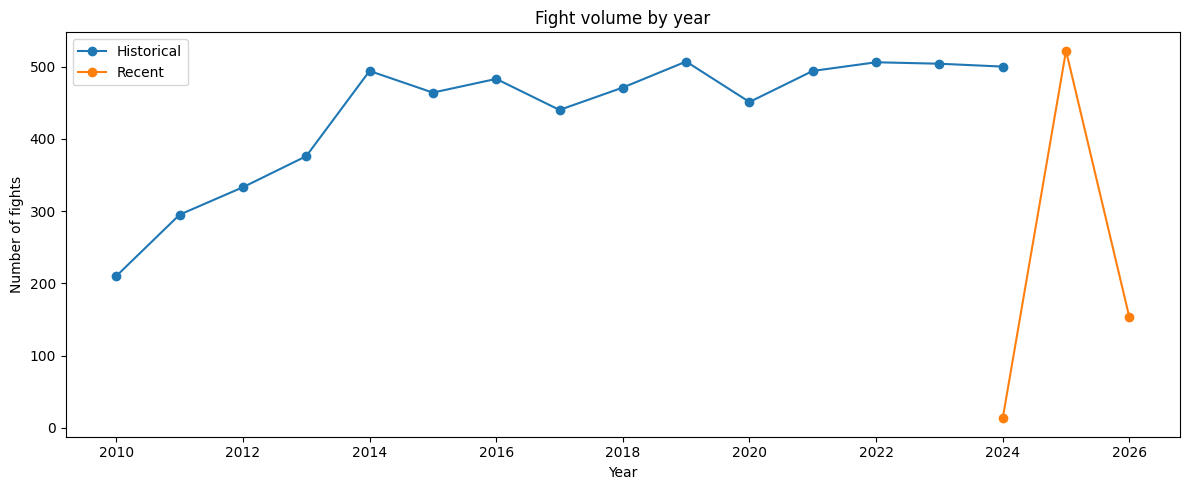

In [5]:
# 5.1 Fight volume over time
fig, ax = plt.subplots(figsize=(12, 5))

hist_yearly = historical.groupby(historical["Date"].dt.year).size()
recent_yearly = recent.groupby(recent["Date"].dt.year).size()

ax.plot(hist_yearly.index, hist_yearly.values, marker="o", label="Historical")
ax.plot(recent_yearly.index, recent_yearly.values, marker="o", label="Recent")
ax.set_title("Fight volume by year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of fights")
ax.legend()
plt.tight_layout()
plt.show()

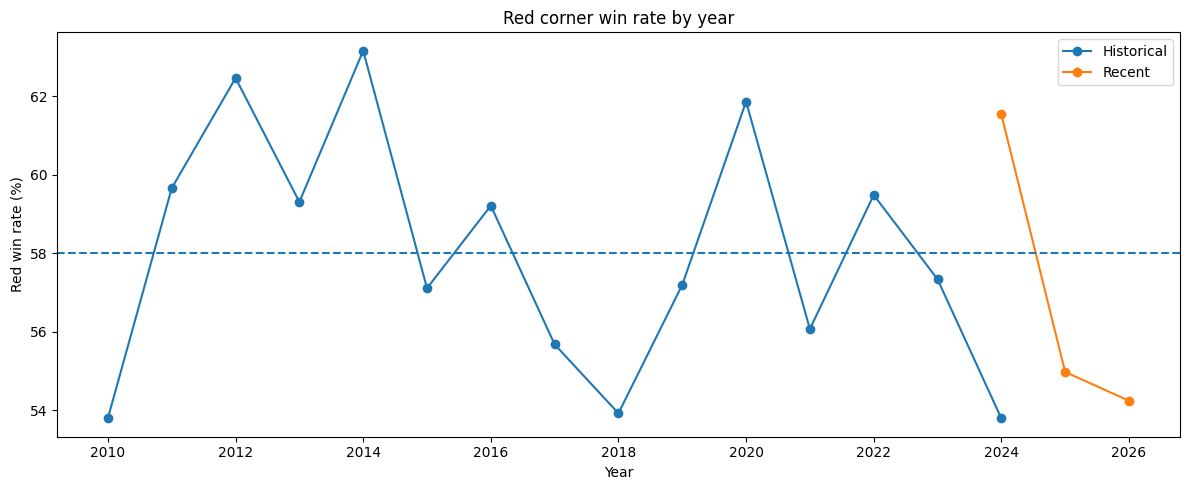

In [6]:
# 5.2 Red side win rate over time
fig, ax = plt.subplots(figsize=(12, 5))

hist_red_rate = historical.groupby(historical["Date"].dt.year)["RedWinner"].mean()
recent_red_rate = recent.groupby(recent["Date"].dt.year)["RedWinner"].mean()

ax.plot(hist_red_rate.index, hist_red_rate.values * 100, marker="o", label="Historical")
ax.plot(recent_red_rate.index, recent_red_rate.values * 100, marker="o", label="Recent")
ax.axhline(historical["RedWinner"].mean() * 100, linestyle="--")
ax.set_title("Red corner win rate by year")
ax.set_xlabel("Year")
ax.set_ylabel("Red win rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

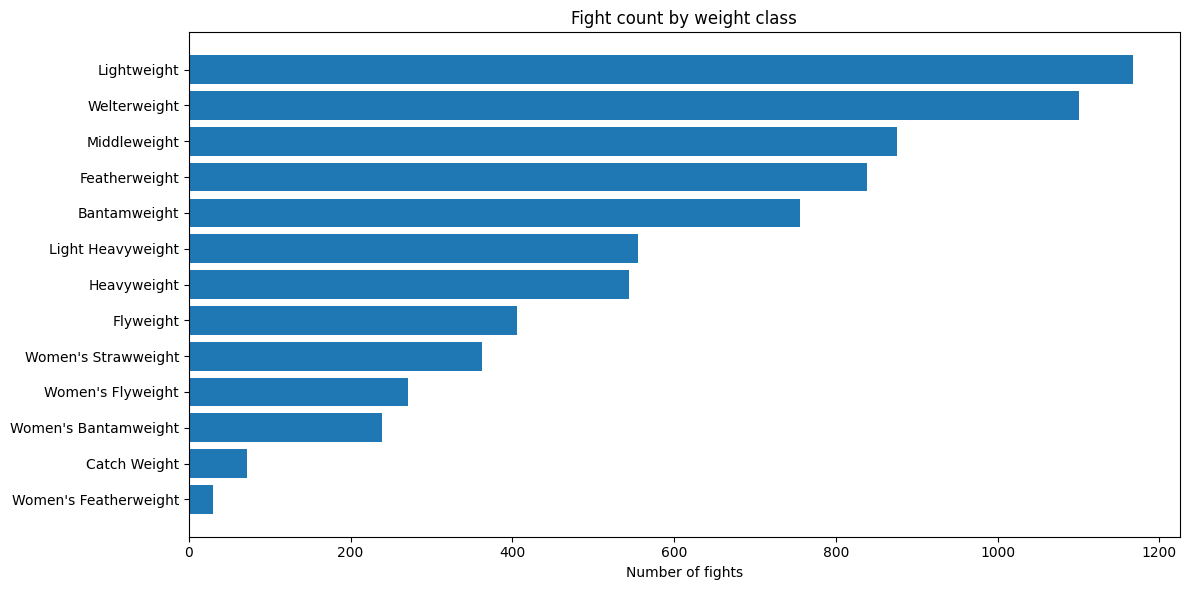

In [7]:
# 5.3 Weight class distribution
fig, ax = plt.subplots(figsize=(12, 6))

weight_counts = all_fights["WeightClass"].value_counts().sort_values(ascending=True)
ax.barh(weight_counts.index, weight_counts.values)
ax.set_title("Fight count by weight class")
ax.set_xlabel("Number of fights")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

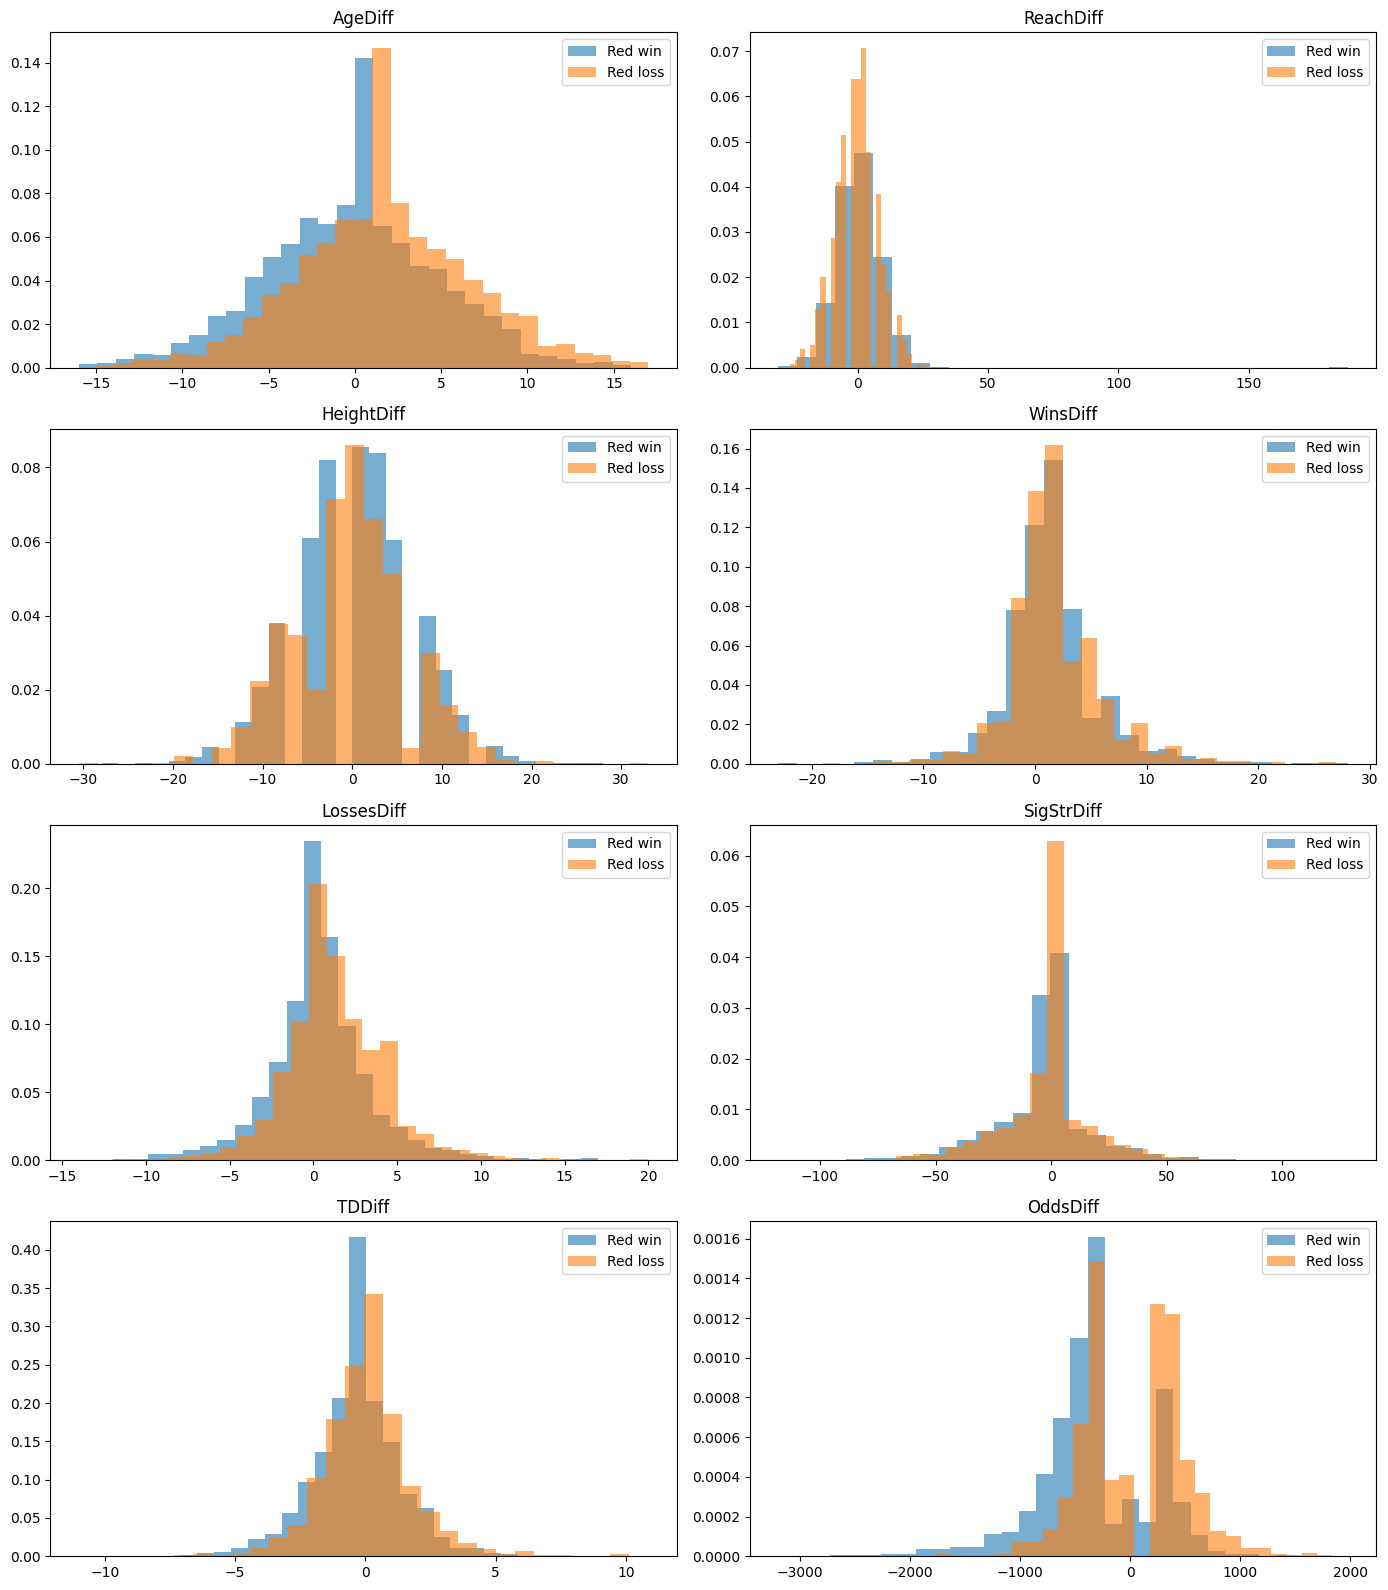

In [8]:
# 5.4 Numeric feature distributions vs outcome
focus_cols = ["AgeDiff", "ReachDiff", "HeightDiff", "WinsDiff", "LossesDiff", "SigStrDiff", "TDDiff", "OddsDiff"]
n = len(focus_cols)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.ravel()

for ax, col in zip(axes, focus_cols):
    win = historical.loc[historical["RedWinner"], col].dropna()
    lose = historical.loc[~historical["RedWinner"], col].dropna()
    ax.hist(win, bins=30, alpha=0.6, label="Red win", density=True)
    ax.hist(lose, bins=30, alpha=0.6, label="Red loss", density=True)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

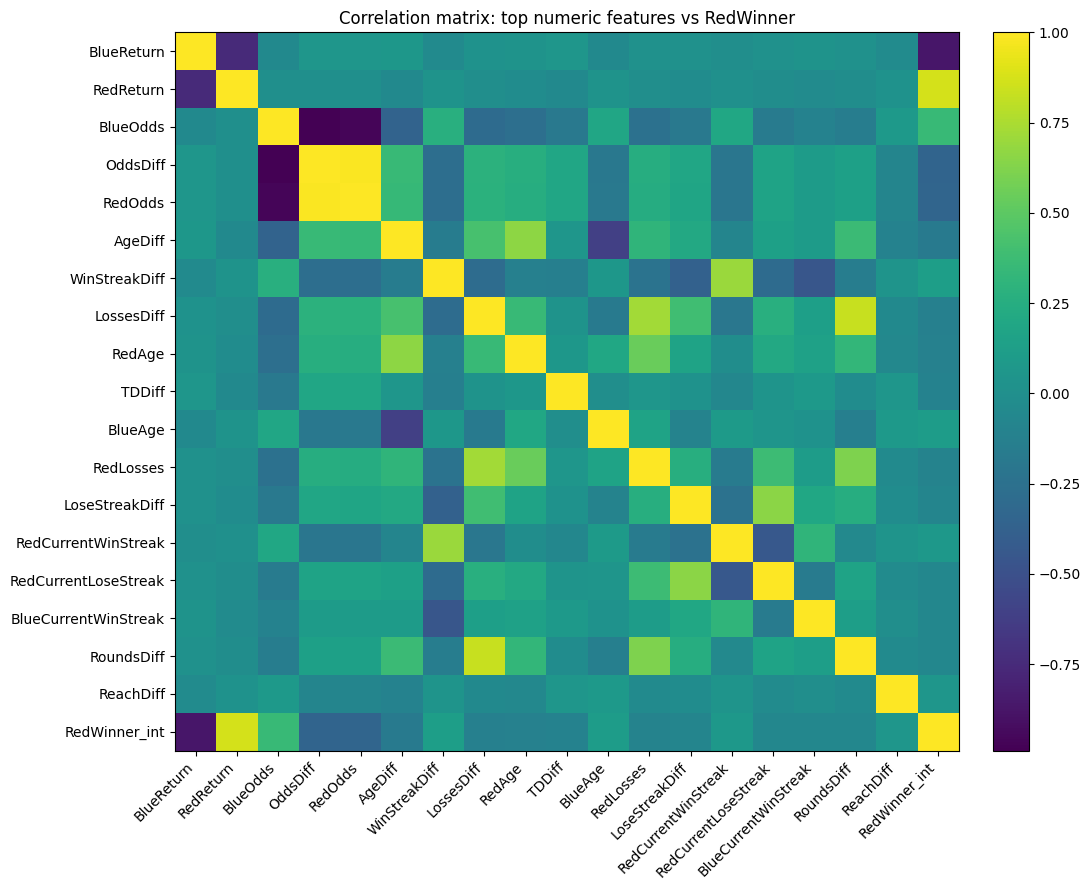

,corr_with_RedWinner
BlueReturn,-0.868956
RedReturn,0.868038
BlueOdds,0.351223
OddsDiff,-0.350499
RedOdds,-0.343601
AgeDiff,-0.177416
WinStreakDiff,0.122979
LossesDiff,-0.120471
RedAge,-0.118835
TDDiff,-0.111017


In [9]:
# 5.5 Correlation heatmap for the most useful numeric features
target_numeric = historical.copy()
target_numeric["RedWinner_int"] = target_numeric["RedWinner"].astype(int)

numeric_cols = target_numeric.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = target_numeric[numeric_cols].corr(numeric_only=True)["RedWinner_int"].drop("RedWinner_int").sort_values(key=lambda s: s.abs(), ascending=False)

top_numeric = corr_with_target.head(18).index.tolist()
corr_matrix = target_numeric[top_numeric + ["RedWinner_int"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix.values, aspect="auto")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Correlation matrix: top numeric features vs RedWinner")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

display(corr_with_target.head(15).to_frame("corr_with_RedWinner"))

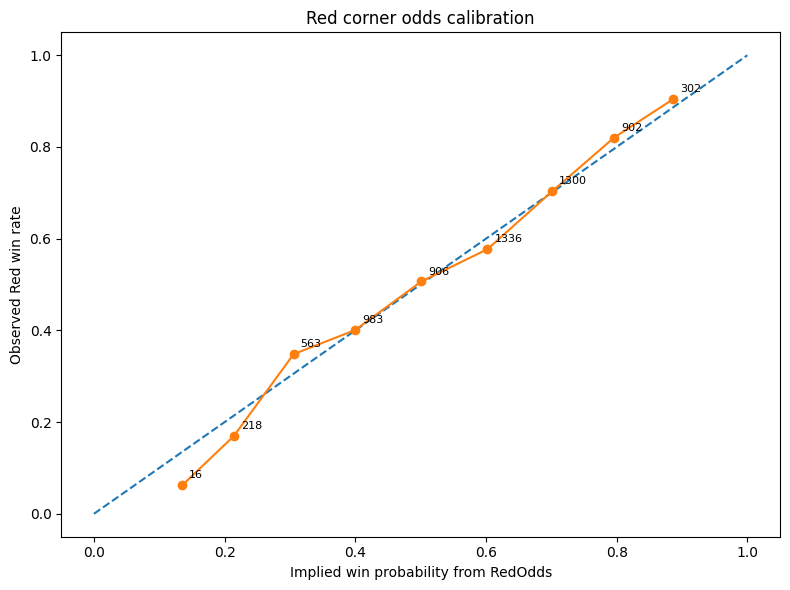

In [10]:
# 5.6 Betting market calibration: implied probability from RedOdds
def american_to_implied_prob(odds: pd.Series) -> pd.Series:
    odds = pd.to_numeric(odds, errors="coerce")
    return np.where(
        odds < 0,
        (-odds) / ((-odds) + 100.0),
        100.0 / (odds + 100.0),
    )

cal = historical[["RedOdds", "RedWinner"]].dropna().copy()
cal["red_implied_prob"] = american_to_implied_prob(cal["RedOdds"])
cal["bucket"] = pd.cut(cal["red_implied_prob"], bins=np.linspace(0.05, 0.95, 10), include_lowest=True)

bucketed = cal.groupby("bucket", observed=True).agg(
    implied_prob=("red_implied_prob", "mean"),
    actual_red_win_rate=("RedWinner", "mean"),
    count=("RedWinner", "size"),
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], linestyle="--")
ax.plot(bucketed["implied_prob"], bucketed["actual_red_win_rate"], marker="o")
for x, y, c in zip(bucketed["implied_prob"], bucketed["actual_red_win_rate"], bucketed["count"]):
    ax.annotate(str(int(c)), (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_title("Red corner odds calibration")
ax.set_xlabel("Implied win probability from RedOdds")
ax.set_ylabel("Observed Red win rate")
plt.tight_layout()
plt.show()


## Why time-based validation matters

Most sports datasets are non-stationary. Fighters improve, decline, switch weight classes, age out of contention, or change training camps over time.

Because of that, random train/test splits can create overly optimistic results by allowing the model to learn patterns from the future.

This notebook instead trains on historical fights and evaluates on the newer 2025–2026 fights. That setup is much closer to a real-world forecasting environment.



## 6) Modeling setup

To keep the analysis honest, the model is evaluated in an **out-of-time** way:

- Train on `testing.csv`  
- Evaluate on `recent_fights.csv`

This mimics a real forecasting scenario much better than a random split.

Three feature sets are compared:

1. **Odds only**  
2. **Skill-only pre-fight features**  
3. **All pre-fight features**  

Again, the post-fight return columns are excluded.


In [11]:
LEAK_COLS = ["RedReturn", "BlueReturn"]
ID_COLS = ["RedFighter", "BlueFighter", "Date"]
TARGET = "RedWinner"

def build_xy(df: pd.DataFrame, feature_mode: str):
    drop_cols = LEAK_COLS + ID_COLS + [TARGET]  # prevent target leakage
    if feature_mode == "odds_only":
        keep = ["RedOdds", "BlueOdds", "OddsDiff"]
        X = df[keep].copy()
    elif feature_mode == "skill_only":
        drop_more = ["RedOdds", "BlueOdds", "OddsDiff"]
        X = df.drop(columns=[c for c in drop_cols + drop_more if c in df.columns]).copy()
    elif feature_mode == "full":
        X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()
    else:
        raise ValueError(feature_mode)

    y = df[TARGET].astype(int).copy()

    # CatBoost likes explicit strings for categoricals and ints for booleans
    for col in X.select_dtypes(include=["bool"]).columns:
        X[col] = X[col].astype(int)
    for col in X.select_dtypes(include=["object"]).columns:
        X[col] = X[col].astype(str).str.strip().replace({"nan": "Unknown", "None": "Unknown"})

    return X, y

def train_eval_catboost(train_df, test_df, feature_mode="full"):
    X_train, y_train = build_xy(train_df, feature_mode)
    X_test, y_test = build_xy(test_df, feature_mode)

    cat_features = [X_train.columns.get_loc(c) for c in X_train.select_dtypes(include=["object"]).columns]

    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    test_pool = Pool(X_test, y_test, cat_features=cat_features)

    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=250,
        depth=6,
        learning_rate=0.06,
        random_seed=SEED,
        verbose=False,
    )
    model.fit(train_pool)

    p_train = model.predict_proba(train_pool)[:, 1]
    p_test = model.predict_proba(test_pool)[:, 1]

    metrics = {
        "feature_set": feature_mode,
        "train_auc": roc_auc_score(y_train, p_train),
        "test_auc": roc_auc_score(y_test, p_test),
        "test_accuracy": accuracy_score(y_test, p_test >= 0.5),
        "test_logloss": log_loss(y_test, p_test),
    }
    return model, X_test, y_test, p_test, metrics

models = {}
rows = []
for feature_mode in ["odds_only", "skill_only", "full"]:
    model, X_test, y_test, p_test, metrics = train_eval_catboost(historical, recent, feature_mode)
    models[feature_mode] = (model, X_test, y_test, p_test)
    rows.append(metrics)

metrics_df = pd.DataFrame(rows).sort_values("test_auc", ascending=False)
display(metrics_df)

,feature_set,train_auc,test_auc,test_accuracy,test_logloss
0,odds_only,0.727850,0.768996,0.700581,0.565738
2,full,0.834355,0.751451,0.687500,0.586368
1,skill_only,0.830907,0.590570,0.597384,0.683515


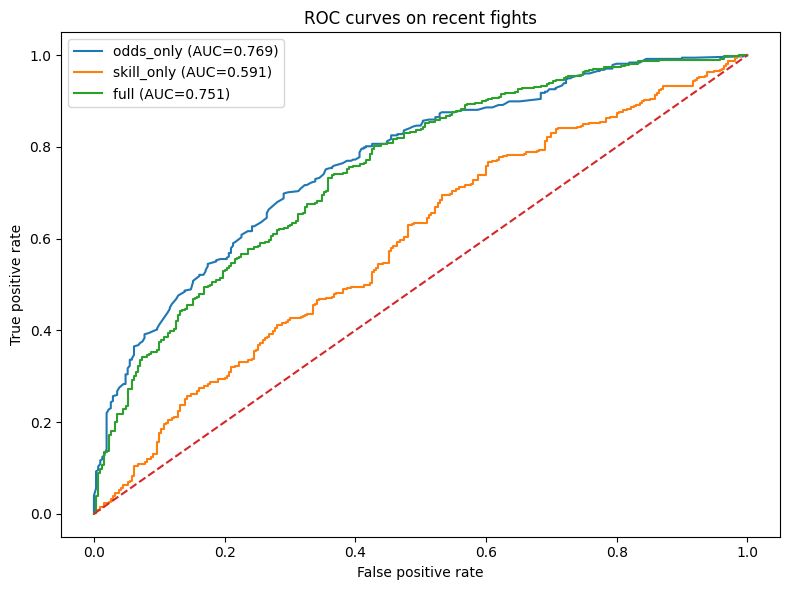

In [12]:
# 6.1 ROC curves for the feature-set comparison
fig, ax = plt.subplots(figsize=(8, 6))

for feature_mode, (_, _, y_test, p_test) in models.items():
    fpr, tpr, _ = roc_curve(y_test, p_test)
    auc = roc_auc_score(y_test, p_test)
    ax.plot(fpr, tpr, label=f"{feature_mode} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC curves on recent fights")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
plt.tight_layout()
plt.show()

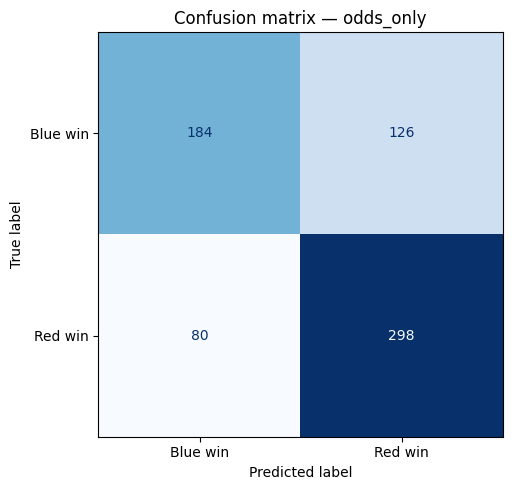

Best feature set: odds_only
AUC: 0.7689964157706093
Accuracy: 0.7005813953488372
Log loss: 0.5657376690220548


In [13]:
# 6.2 Confusion matrix for the best model
best_mode = metrics_df.iloc[0]["feature_set"]
best_model, X_test, y_test, p_test = models[best_mode]

pred_label = (p_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_label)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Blue win", "Red win"])
disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
ax.set_title(f"Confusion matrix — {best_mode}")
plt.tight_layout()
plt.show()

print("Best feature set:", best_mode)
print("AUC:", roc_auc_score(y_test, p_test))
print("Accuracy:", accuracy_score(y_test, pred_label))
print("Log loss:", log_loss(y_test, p_test))

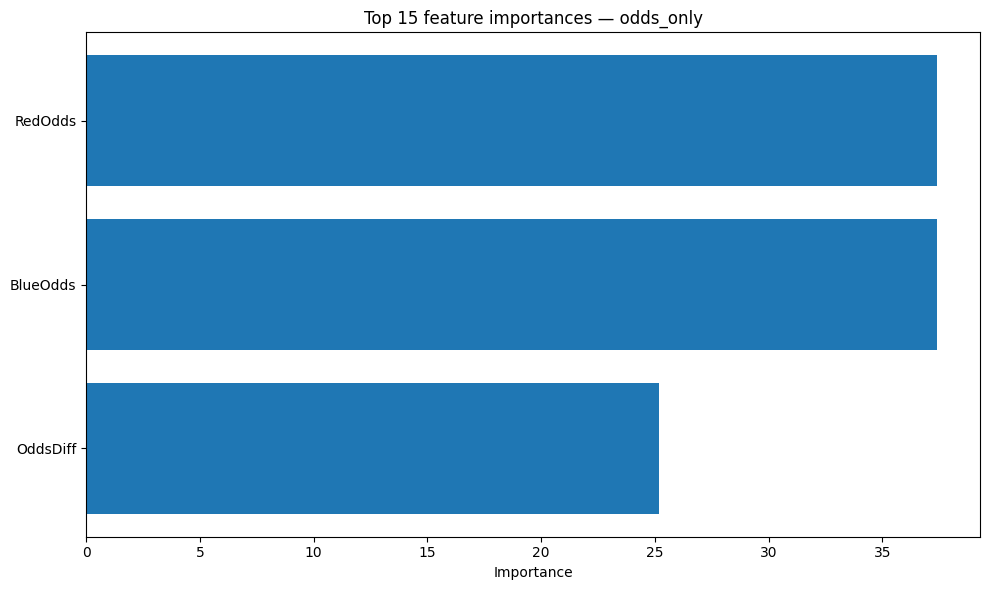

,importance
RedOdds,37.416748
BlueOdds,37.396467
OddsDiff,25.186784


In [14]:
# 6.3 Feature importance from the best model
X_train_full, y_train_full = build_xy(historical, best_mode)
cat_features = [X_train_full.columns.get_loc(c) for c in X_train_full.select_dtypes(include=["object"]).columns]
train_pool = Pool(X_train_full, y_train_full, cat_features=cat_features)

final_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=250,
    depth=6,
    learning_rate=0.06,
    random_seed=SEED,
    verbose=False,
)
final_model.fit(train_pool)

importances = pd.Series(final_model.get_feature_importance(train_pool), index=X_train_full.columns).sort_values(ascending=False)

top_n = 15
fig, ax = plt.subplots(figsize=(10, 6))
top_importances = importances.head(top_n).sort_values(ascending=True)
ax.barh(top_importances.index, top_importances.values)
ax.set_title(f"Top {top_n} feature importances — {best_mode}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

display(importances.head(20).to_frame("importance"))

## 7) Interpretation

Several clear patterns emerge from the analysis and modeling results.

The betting market is highly informative for UFC prediction. Even using odds-related features alone produces strong predictive performance, showing that pre-fight betting lines already capture a large amount of available information.

The exploratory analysis also reveals a mild distribution shift between the historical and recent fight datasets. The red-corner win rate changes slightly across time periods, which supports the decision to use a time-based train/test split instead of a random split.

Data quality is generally strong across both datasets. Most missing values are concentrated in odds-related columns, while the remaining features are relatively complete and usable for modeling.

After removing leakage-related features, the model results become much more realistic and reliable. The final workflow represents a proper forecasting setup rather than accidental target reconstruction.

Overall, the analysis suggests that:

- Betting odds are the strongest pre-fight predictive signal
- Fighter-level statistical differences still provide additional value
- Time-aware validation is important in sports analytics because fight trends evolve over time
- Clean feature selection and leakage prevention are critical for trustworthy results

## 8) Final Takeaways

### Key Findings

- Betting odds provide a very strong baseline for UFC fight prediction
- Fighter statistics and matchup-level features still contain useful predictive signal
- The datasets are relatively clean and suitable for machine learning workflows
- Time-based validation produces more realistic performance estimates than random splits
- Leakage prevention is essential when working with sports datasets

---

### Modeling Summary

The notebook combines:
- Exploratory Data Analysis (EDA)
- Feature engineering
- Visualization-driven insights
- Machine learning benchmarking
- Time-aware evaluation

The final modeling workflow uses historical fights for training and newer fights for testing, creating a more realistic forecasting environment.

---

### Potential Future Improvements

Several additions could further improve predictive performance:

1. Rolling fighter form metrics  
2. Win streak and momentum features  
3. Elo-based fighter ratings  
4. Historical sequence modeling  
5. Ensemble learning approaches  
6. Training camp and location-based features  
7. More advanced fighter efficiency metrics

---

## Final Thoughts

This analysis explored UFC fight trends using historical and recent bout data through April 2026.

The results show that betting odds remain highly informative, while fighter-level statistical features still contribute meaningful predictive signal. Using a time-based validation setup also highlights the importance of evaluating sports models in a realistic forecasting environment.